# Dev33: Apply 057 SVM Model to 028 Crop Regions

**Goal**: Use the trained SVM from dev20 (trained on 057) and apply it to 028 crop regions (inverse of dev30).

**Workflow**:
1. Load saved SVM model from dev20 (057-trained, 3 classes)
2. Load and preprocess 028 transect (same preprocessing as dev20)
3. Classify the 4 crop regions from dev30
4. Visualize with plot_classification_as_image

**Key difference from dev30**:
- Dev30: 5-class SVM (sediment, rust, dark_bomb, dark_pit, halo) → classify 028 crops
- Dev33: 3-class SVM (training_dark, training_sediment, training_bombs) → classify 028 crops

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

sys.path.append(os.path.abspath("../"))

# Force complete module reload
if "utils.gref_pipeline.georef" in sys.modules:
    del sys.modules["utils.gref_pipeline.georef"]
if "utils.gref_pipeline" in sys.modules:
    del sys.modules["utils.gref_pipeline"]
if "gref_pipeline.georef" in sys.modules:
    del sys.modules["gref_pipeline.georef"]

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

print("✅ Module reloaded with cache cleared!")

✅ Module reloaded with cache cleared!


## Step 1: Load Trained SVM Model from dev20

**Note**: First run the save cell in dev20 to create the model file!

In [2]:
# Load the saved SVM model and preprocessing info
model_file = "./saved_data/svm_model_057_3class.pkl"

if not os.path.exists(model_file):
    print("❌ ERROR: Model file not found!")
    print(f"   Looking for: {model_file}")
    print("\n📝 TO CREATE THE MODEL FILE:")
    print("   1. Open dev20 notebook")
    print("   2. Run all cells up to 'Train SVM'")
    print("   3. Run the '💾 SAVE SVM MODEL' cell")
    print("   4. Then come back here!")
    raise FileNotFoundError(f"Model file not found: {model_file}")
else:
    with open(model_file, "rb") as f:
        saved_model_data = pickle.load(f)

    # Extract model and parameters
    trained_model = saved_model_data["model"]
    class_names = saved_model_data["class_names"]
    label_encoder = saved_model_data["label_encoder"]
    preprocessing_params = saved_model_data["preprocessing"]
    best_params = saved_model_data["best_params"]

    print("✅ SVM model loaded successfully!")
    print(f"\n📊 Model Info:")
    print(f"   Classes: {class_names}")
    print(f"   Best C: {best_params['C']}")
    print(f"   Best gamma: {best_params['gamma']}")
    print(f"\n🔬 Preprocessing (will apply to 028):")
    print(f"   Wavelength range: {preprocessing_params['wavelength_range']} nm")
    print(f"   Smoothing: {preprocessing_params['smoothing_method']}")
    print(f"   Normalization: {preprocessing_params['normalization']}")

✅ SVM model loaded successfully!

📊 Model Info:
   Classes: ['training_dark', 'training_sediment', 'training_bombs']
   Best C: 0.1
   Best gamma: 0.1

🔬 Preprocessing (will apply to 028):
   Wavelength range: (490, 680) nm
   Smoothing: None
   Normalization: None


## Step 2: Load 028 Transect (All 5 Files)

Same as dev30 - we load all 5 files to cover the crop regions.

In [3]:
# Load 028 transect
transect = load_transect(r"E:\mjosa_new_oct_2025\use_gref4hsi\028\output")
transect.list_files()

# Select all 5 files from transect 028
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)


   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
   • rad_uhi_20241029_125028_4
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
   • rad_uhi_20241029_125028_5
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (10027, 968), RGB (10027, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_125028_1...
✅ Combined shapes: X/Y/Z (10027, 968), RGB (10027, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_125028_1...
   • Loading rad_uhi_20241029_125028_2...
   • Load

In [4]:
# Apply illumination correction
cube.apply_illumination_correction_v2()
print("✅ Illumination correction applied")

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied


## Step 3: Apply Same Preprocessing as dev30

In [5]:
# Apply spectral smoothing (same as dev20) - only if smoothing was used
if preprocessing_params["smoothing_method"] is not None:
    cube.apply_spectral_smoothing(
        method=preprocessing_params["smoothing_method"],
        gaussian_sigma=preprocessing_params["smoothing_sigma"],
    )
    print(
        f"✅ Spectral smoothing applied: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
    )
else:
    print("✅ No spectral smoothing (matching dev20 - raw spectral features)")

✅ No spectral smoothing (matching dev20 - raw spectral features)


In [6]:
# Crop wavelengths (same as dev30)
wl_min, wl_max = preprocessing_params["wavelength_range"]
cube.apply_wavelength_filter(wavelength_range=(wl_min, wl_max))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube.data_corrected.shape}")
print(f"   Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm")

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-680 nm
✂️  Filtered wavelengths: 108
📉 Range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (10027, 968, 108)
   Memory: 3.91 GB
✅ Wavelength cropping complete
   Cropped shape: (10027, 968, 108)
   Wavelength range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (10027, 968, 108)
   Memory: 3.91 GB
✅ Wavelength cropping complete
   Cropped shape: (10027, 968, 108)
   Wavelength range: 490.2 - 679.4 nm


In [7]:
# Check if normalization was used in dev20
if preprocessing_params["normalization"] is not None:
    print(f"✅ Normalization: {preprocessing_params['normalization']}")
    # Add normalization code here if needed
else:
    print("✅ No normalization applied (matching dev20 preprocessing)")

✅ No normalization applied (matching dev20 preprocessing)


## Step 4: Define Crop Regions (Same as dev30)

## Step 5: Set the Loaded Model on the Cube

The `classify_segment()` method uses the model stored in the cube object. We need to set it manually.

In [8]:
# Set the loaded model on the cube object
# (classify_segment() expects these attributes to exist)
cube.svm_model = trained_model
cube.svm_label_encoder = label_encoder
cube.svm_class_names = class_names

print("✅ Model set on cube object")
print(f"   cube.svm_model: {type(cube.svm_model)}")
print(f"   cube.svm_label_encoder: {type(cube.svm_label_encoder)}")
print(f"   cube.svm_class_names: {cube.svm_class_names}")

✅ Model set on cube object
   cube.svm_model: <class 'sklearn.svm._classes.SVC'>
   cube.svm_label_encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
   cube.svm_class_names: ['training_dark', 'training_sediment', 'training_bombs']


In [9]:
# Define crop regions (UPDATED coordinates from user)
crop_regions = [
    {
        "name": "Crop 1 (Bomb 2 - Rust)",
        "track": 1258,
        "slit": 250,  # UPDATED from 212
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 2 (Bomb 3)",
        "track": 5592,
        "slit": 700,  # UPDATED from 765
        "width": 500,
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 3 (Bomb 1)",
        "track": 5160,
        "slit": 613,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 4 (Dark pits)",
        "track": 717,
        "slit": 385,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
]

print(f"📍 Defined {len(crop_regions)} crop regions (UPDATED):")
for i, crop in enumerate(crop_regions, 1):
    print(
        f"   {i}. {crop['name']}: track={crop['track']}, slit={crop['slit']}, width={crop['width']}"
    )

📍 Defined 4 crop regions (UPDATED):
   1. Crop 1 (Bomb 2 - Rust): track=1258, slit=250, width=500
   2. Crop 2 (Bomb 3): track=5592, slit=700, width=500
   3. Crop 3 (Bomb 1): track=5160, slit=613, width=500
   4. Crop 4 (Dark pits): track=717, slit=385, width=500


In [10]:
# Helper function to classify a single crop region (same as dev30)
def test_classify_crop_region_dev33(cube, crop, confidence_threshold=0.5):
    """Classify a cropped region and return results."""
    # Calculate crop bounds
    half_width_slit = crop["width"] // 2
    half_width_track = int(crop["width"] / crop["aspect_ratio"] / 2)

    crop_track_min = max(0, crop["track"] - half_width_track)
    crop_track_max = min(cube.data_corrected.shape[0], crop["track"] + half_width_track)
    crop_slit_min = max(0, crop["slit"] - half_width_slit)
    crop_slit_max = min(cube.data_corrected.shape[1], crop["slit"] + half_width_slit)

    print(f"\n🔍 Classifying: {crop['name']}")
    print(
        f"   Crop bounds: track [{crop_track_min}:{crop_track_max}], slit [{crop_slit_min}:{crop_slit_max}]"
    )

    # Classify the segment
    classification_results = cube.classify_segment(
        segment_start=crop_track_min,
        segment_end=crop_track_max - 1,
        use_corrected=True,
        confidence_threshold=confidence_threshold,
        quiet=False,
    )

    # Print pixel counts
    print(f"\n📊 Pixel counts for {crop['name']}:")
    for class_name in classification_results["class_names"]:
        count = np.sum(classification_results["classification_map"] == class_name)
        percentage = 100.0 * count / classification_results["classification_map"].size
        print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")

    return classification_results, crop_track_min, crop_track_max


# Classify all 4 crop regions
crop_results = []

for crop in crop_regions:
    results, track_min, track_max = test_classify_crop_region_dev33(
        cube, crop, confidence_threshold=0.5
    )
    crop_results.append(
        {
            "crop": crop,
            "results": results,
            "track_min": track_min,
            "track_max": track_max,
        }
    )

print(f"\n✅ All {len(crop_results)} crop regions classified!")


🔍 Classifying: Crop 1 (Bomb 2 - Rust)
   Crop bounds: track [1196:1320], slit [0:500]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 1196 to 1319

🔪 Extracting segment...
   Segment shape: (124, 968, 108)

🤖 Classifying 120032 pixels...


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:15<00:00, 7677.12pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 14807 (12.3%)
   Confidence range: [0.336, 1.000]
   ✅ Classification complete in 15.73 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 2 pixels (0.0%)
   classified_dark: 13942 pixels (11.6%)
   classified_sediment: 91281 pixels (76.0%)
   classified_unknown: 14807 pixels (12.3%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 1 (Bomb 2 - Rust):
   classified_dark: 13942 pixels (11.6%)
   classified_sediment: 91281 pixels (76.0%)
   classified_bombs: 2 pixels (0.0%)
   classified_unknown: 14807 pixels (12.3%)

🔍 Classifying: Crop 2 (Bomb 3)
   Crop bounds: track [5530:5654], slit [450:950]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 5530 to 5653

🔪 Extr

   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:13<00:00, 8665.69pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 6124 (5.1%)
   Confidence range: [0.347, 0.990]
   ✅ Classification complete in 13.90 seconds

📊 Classification distribution (before filtering):
   classified_dark: 4446 pixels (3.7%)
   classified_sediment: 109462 pixels (91.2%)
   classified_unknown: 6124 pixels (5.1%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 2 (Bomb 3):
   classified_dark: 4446 pixels (3.7%)
   classified_sediment: 109462 pixels (91.2%)
   classified_bombs: 0 pixels (0.0%)
   classified_unknown: 6124 pixels (5.1%)

🔍 Classifying: Crop 3 (Bomb 1)
   Crop bounds: track [5098:5222], slit [363:863]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 5098 to 5221

🔪 Extracting segment...
   Segment shape: (124, 968, 108)


   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:16<00:00, 7061.79pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 11674 (9.7%)
   Confidence range: [0.336, 0.999]
   ✅ Classification complete in 17.08 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 2 pixels (0.0%)
   classified_dark: 10211 pixels (8.5%)
   classified_sediment: 98145 pixels (81.8%)
   classified_unknown: 11674 pixels (9.7%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 3 (Bomb 1):
   classified_dark: 10211 pixels (8.5%)
   classified_sediment: 98145 pixels (81.8%)
   classified_bombs: 2 pixels (0.0%)
   classified_unknown: 11674 pixels (9.7%)

🔍 Classifying: Crop 4 (Dark pits)
   Crop bounds: track [655:779], slit [135:635]
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 655 to 778

🔪 Extracting segmen

   Classifying: 100%|█████████████████████████████████| 120032/120032 [00:17<00:00, 6697.68pixels/s]


🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 2156 (1.8%)
   Confidence range: [0.345, 0.997]
   ✅ Classification complete in 17.99 seconds

📊 Classification distribution (before filtering):
   classified_dark: 1291 pixels (1.1%)
   classified_sediment: 116585 pixels (97.1%)
   classified_unknown: 2156 pixels (1.8%)

✅ Classification and validation complete!

📊 Pixel counts for Crop 4 (Dark pits):
   classified_dark: 1291 pixels (1.1%)
   classified_sediment: 116585 pixels (97.1%)
   classified_bombs: 0 pixels (0.0%)
   classified_unknown: 2156 pixels (1.8%)

✅ All 4 crop regions classified!


## Step 6: Classify Each Crop Region

Use the 057-trained model to classify all 4 crop regions separately.

📊 Plotting classification results for each crop region...

📍 Crop 1 (Bomb 2 - Rust)
   ROIs: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
      classified_bombs: 2 pixels
      classified_dark: 13942 pixels
      classified_sediment: 91281 pixels
      classified_unknown: 14807 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🔍 DEBUG ROI 'classified_dark': 10611 pixels
   First 3 original: slit=[358, 359, 360], track=[1196, 1196, 1196]
   First 3 transformed: x=[142, 141, 140], y=[1196, 1196, 1196]
   Extent: x=[0, 500], y=[1196, 1320]
🔍 DEBUG ROI 'cla

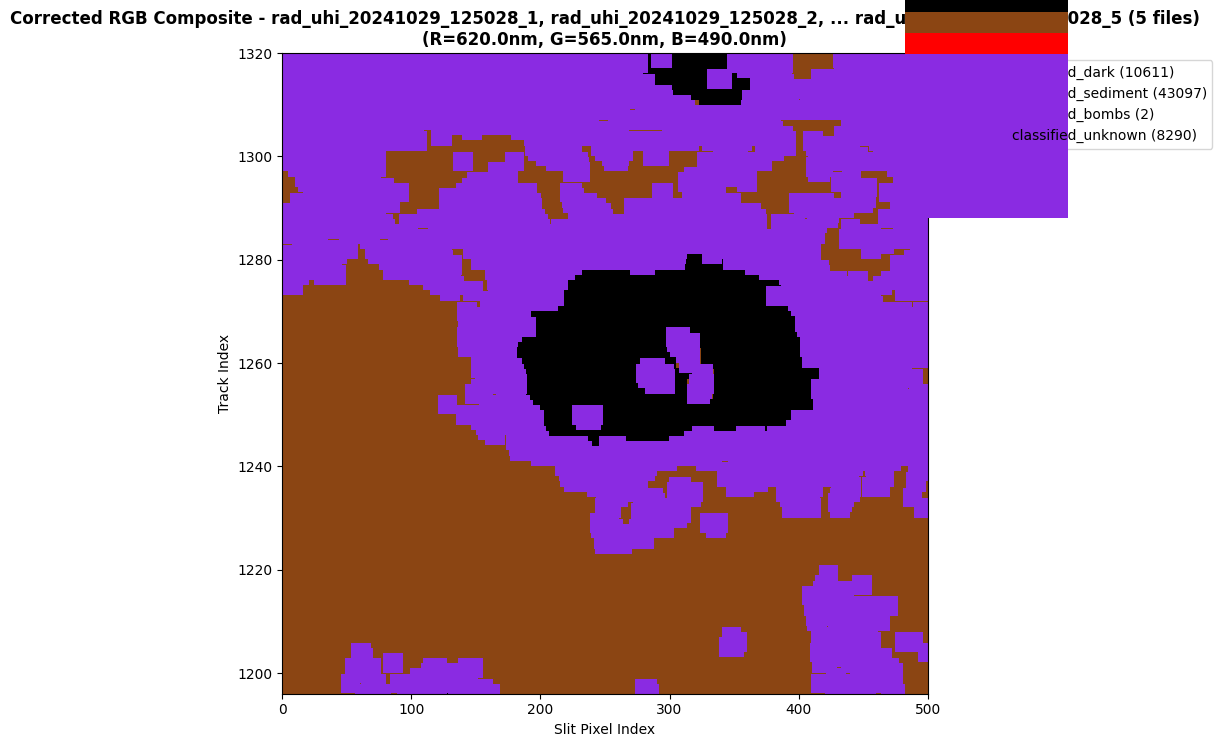


📍 Crop 2 (Bomb 3)
   ROIs: ['classified_dark', 'classified_sediment', 'classified_unknown']
      classified_dark: 4446 pixels
      classified_sediment: 109462 pixels
      classified_unknown: 6124 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🔍 DEBUG ROI 'classified_dark': 2651 pixels
   First 3 original: slit=[949, 696, 475], track=[5536, 5540, 5544]
   First 3 transformed: x=[451, 704, 925], y=[5536, 5540, 5544]
   Extent: x=[450, 950], y=[5530, 5654]
🔍 DEBUG ROI 'classified_sediment': 56323 pixels
   First 3 original: slit=[450, 451, 452], track=[5530, 5530, 5530]
   First 3 tra

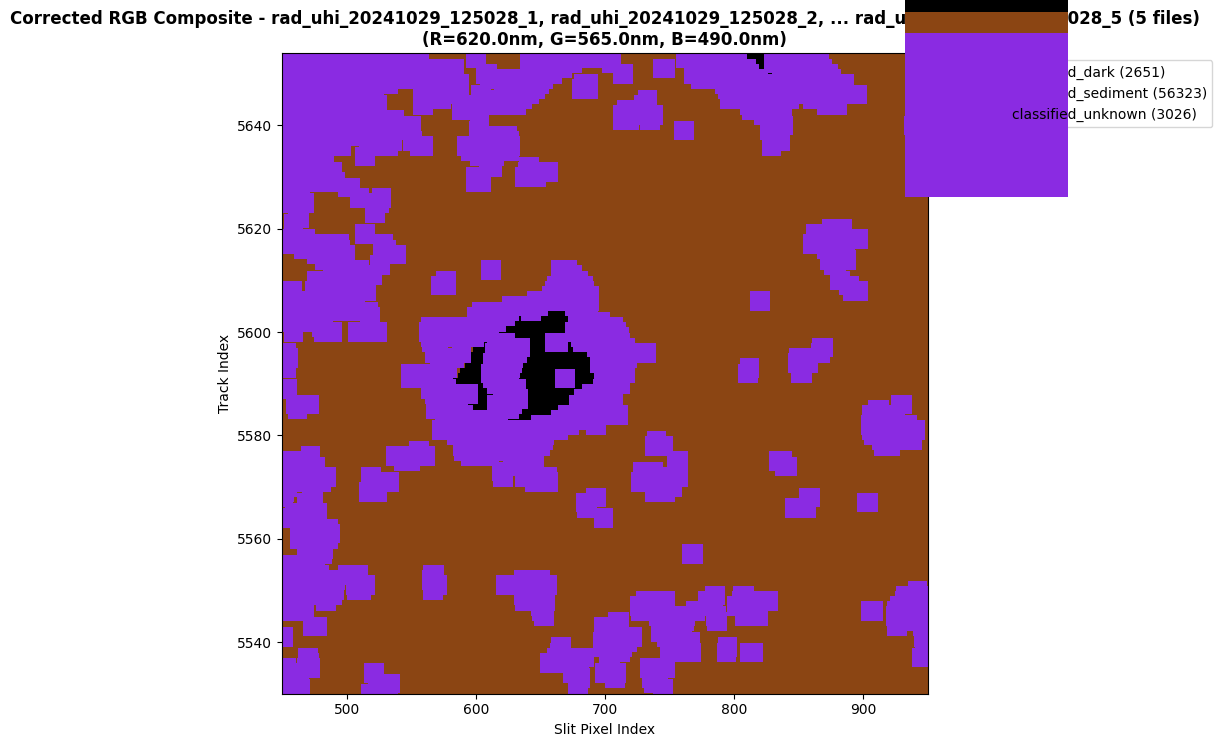


📍 Crop 3 (Bomb 1)
   ROIs: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
      classified_bombs: 2 pixels
      classified_dark: 10211 pixels
      classified_sediment: 98145 pixels
      classified_unknown: 11674 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🔍 DEBUG ROI 'classified_dark': 8809 pixels
   First 3 original: slit=[429, 439, 441], track=[5098, 5098, 5098]
   First 3 transformed: x=[797, 787, 785], y=[5098, 5098, 5098]
   Extent: x=[363, 863], y=[5098, 5222]
🔍 DEBUG ROI 'classified_sediment': 44528 pixels
   First 3 original: slit=[3

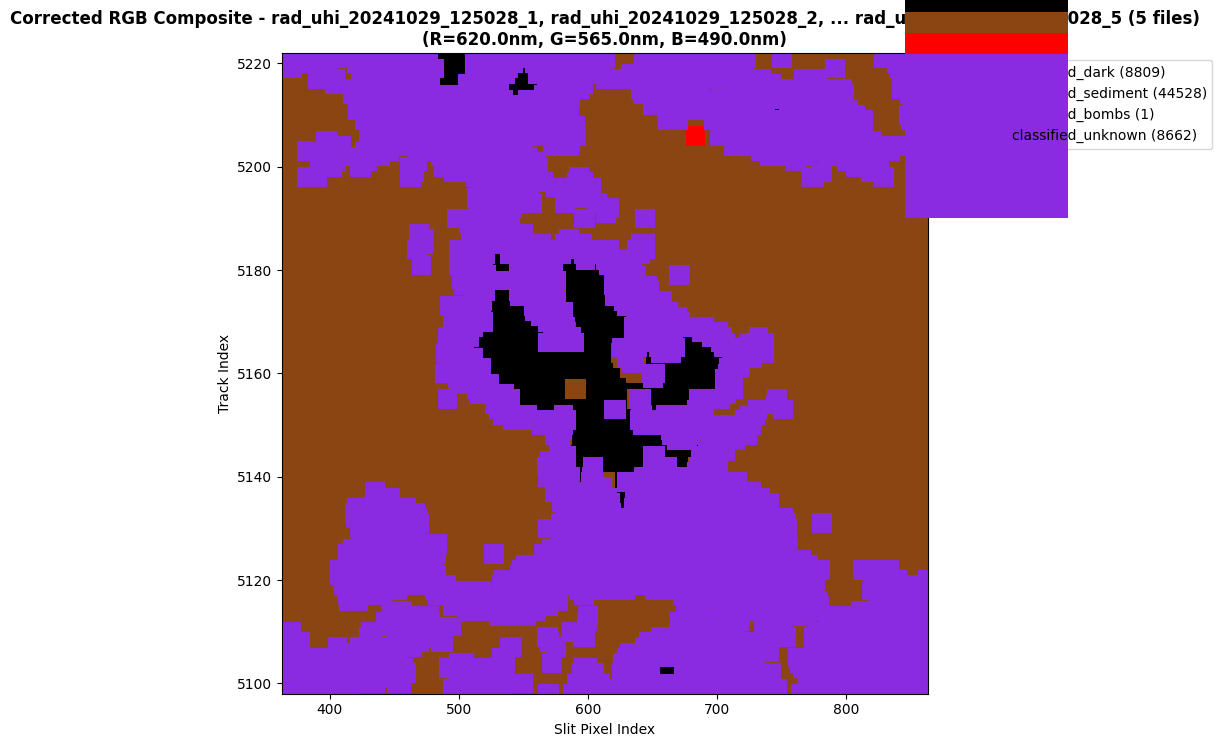


📍 Crop 4 (Dark pits)
   ROIs: ['classified_dark', 'classified_sediment', 'classified_unknown']
      classified_dark: 1291 pixels
      classified_sediment: 116585 pixels
      classified_unknown: 2156 pixels
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🔍 DEBUG ROI 'classified_dark': 900 pixels
   First 3 original: slit=[368, 378, 383], track=[708, 708, 708]
   First 3 transformed: x=[402, 392, 387], y=[708, 708, 708]
   Extent: x=[135, 635], y=[655, 779]
🔍 DEBUG ROI 'classified_sediment': 60231 pixels
   First 3 original: slit=[135, 136, 137], track=[655, 655, 655]
   First 3 transformed: x=[63

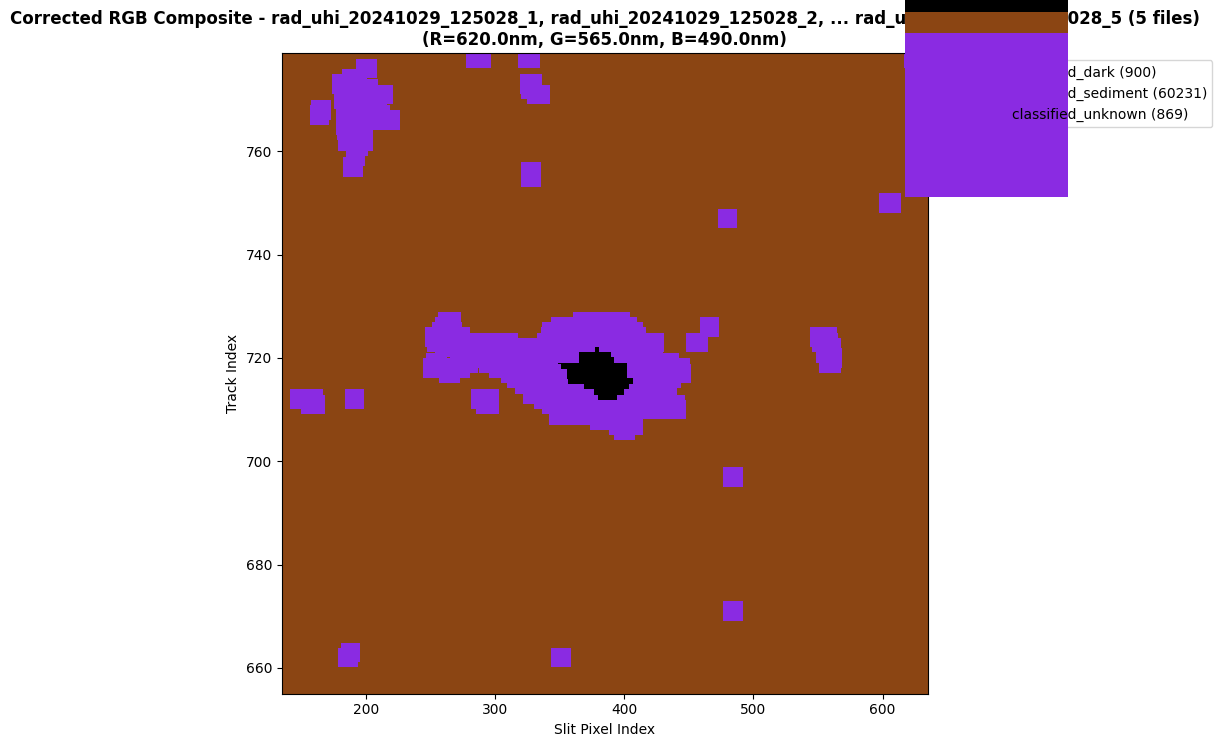

In [11]:
%matplotlib inline

# Plot each crop region separately with plot_rgb (same as dev30)
print("📊 Plotting classification results for each crop region...")

for crop_result in crop_results:
    crop = crop_result["crop"]
    results = crop_result["results"]
    track_min = crop_result["track_min"]

    # Create ROI collection from classification map
    classification_rois = {}
    for class_name in results["class_names"]:
        mask = results["classification_map"] == class_name
        rows, cols = np.where(mask)
        # Convert to global coordinates (add track_min offset)
        pixels = [(col, row + track_min) for row, col in zip(rows, cols)]
        if len(pixels) > 0:
            classification_rois[class_name] = pixels

    print(f"\n📍 {crop['name']}")
    print(f"   ROIs: {list(classification_rois.keys())}")
    for class_name in sorted(classification_rois.keys()):
        print(f"      {class_name}: {len(classification_rois[class_name])} pixels")

    # Plot with plot_rgb (same visualization as dev30)
    cube.plot_rgb(
        use_corrected=True,
        flip_axes=True,
        flip_horizontal=True,
        figsize=(30, 8.32),
        crop_center_track=crop["track"],
        crop_center_slit=crop["slit"],
        crop_width=crop["width"],
        crop_aspect_ratio=crop["aspect_ratio"],
        display_aspect_ratio=4.0,
        show_file_boundaries=False,
        roi_collection=classification_rois,
        roi_legend_loc="outside",
        roi_marker_size=2,
        roi_legend_markersize=50,
        roi_marker_edgewidth=0,
    )

## Summary

**What we did:**
1. ✅ Loaded SVM model trained on 057 transect (dev20, 3 classes)
2. ✅ Applied same preprocessing to 028 transect
3. ✅ Defined 4 crop regions (same as dev30)
4. ✅ Classified each crop region separately using 057's model
5. ✅ Visualized each crop with plot_rgb

**Key insight**: Testing if the 057-trained model (3 classes) generalizes to 028 crop regions!

📊 Plotting classification as IMAGES (not ROI markers)...

📍 Crop 1 (Bomb 2 - Rust)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
   Original shape: (124, 968)
   Cropped to slit [0:500]: (124, 500)
   Pixel counts:
      classified_dark: 10611 pixels (17.1%)
      classified_sediment: 43097 pixels (69.5%)
      classified_bombs: 2 pixels (0.0%)
      classified_unknown: 8290 pixels (13.4%)


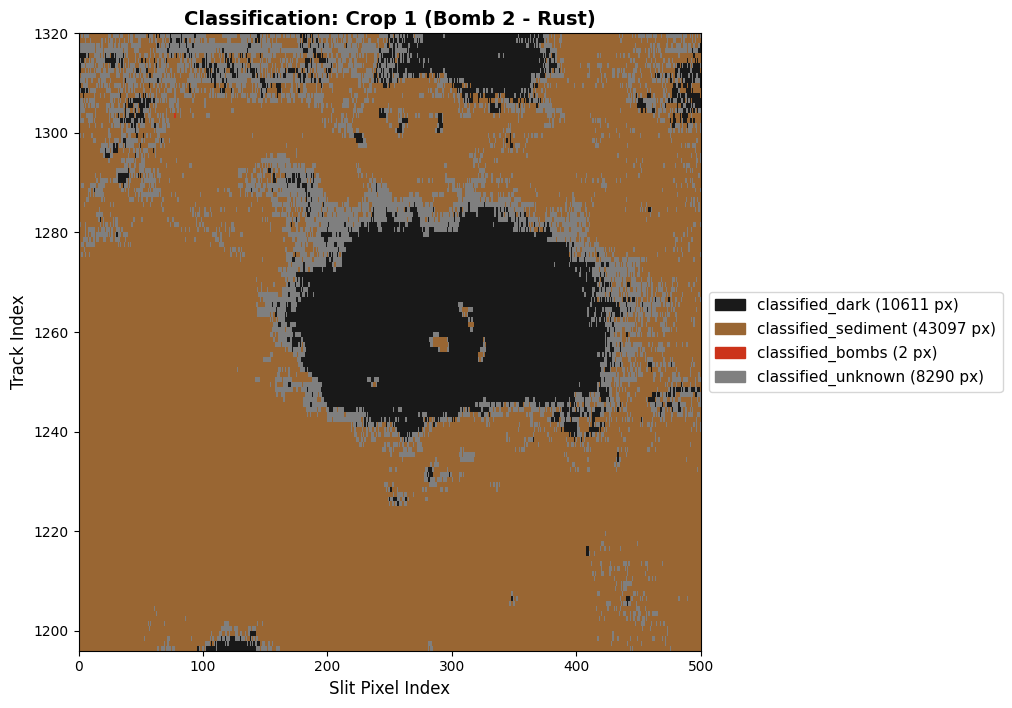


📍 Crop 2 (Bomb 3)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
   Original shape: (124, 968)
   Cropped to slit [450:950]: (124, 500)
   Pixel counts:
      classified_dark: 2651 pixels (4.3%)
      classified_sediment: 56323 pixels (90.8%)
      classified_bombs: 0 pixels (0.0%)
      classified_unknown: 3026 pixels (4.9%)


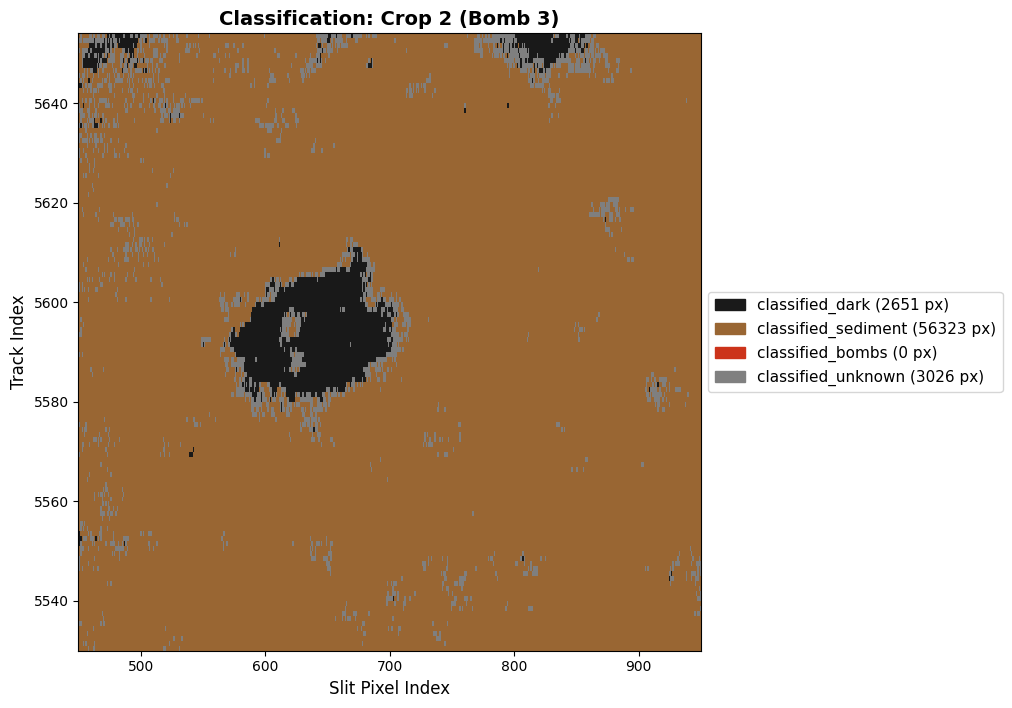


📍 Crop 3 (Bomb 1)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
   Original shape: (124, 968)
   Cropped to slit [363:863]: (124, 500)
   Pixel counts:
      classified_dark: 8809 pixels (14.2%)
      classified_sediment: 44528 pixels (71.8%)
      classified_bombs: 1 pixels (0.0%)
      classified_unknown: 8662 pixels (14.0%)


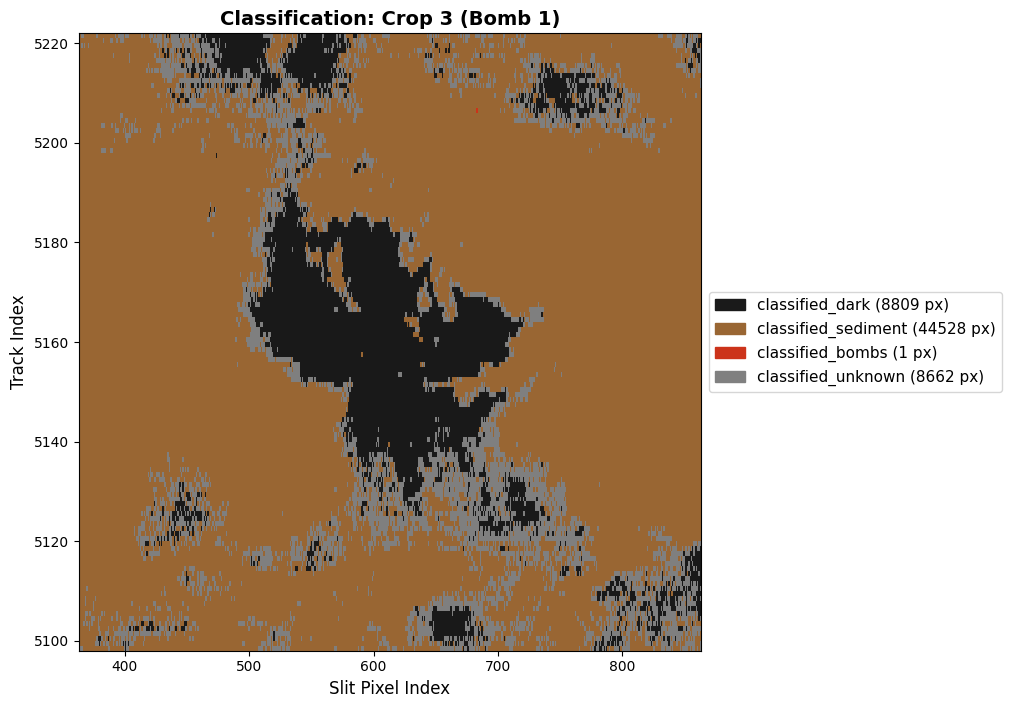


📍 Crop 4 (Dark pits)
   Classes: ['classified_dark', 'classified_sediment', 'classified_bombs', 'classified_unknown']
   Original shape: (124, 968)
   Cropped to slit [135:635]: (124, 500)
   Pixel counts:
      classified_dark: 900 pixels (1.5%)
      classified_sediment: 60231 pixels (97.1%)
      classified_bombs: 0 pixels (0.0%)
      classified_unknown: 869 pixels (1.4%)


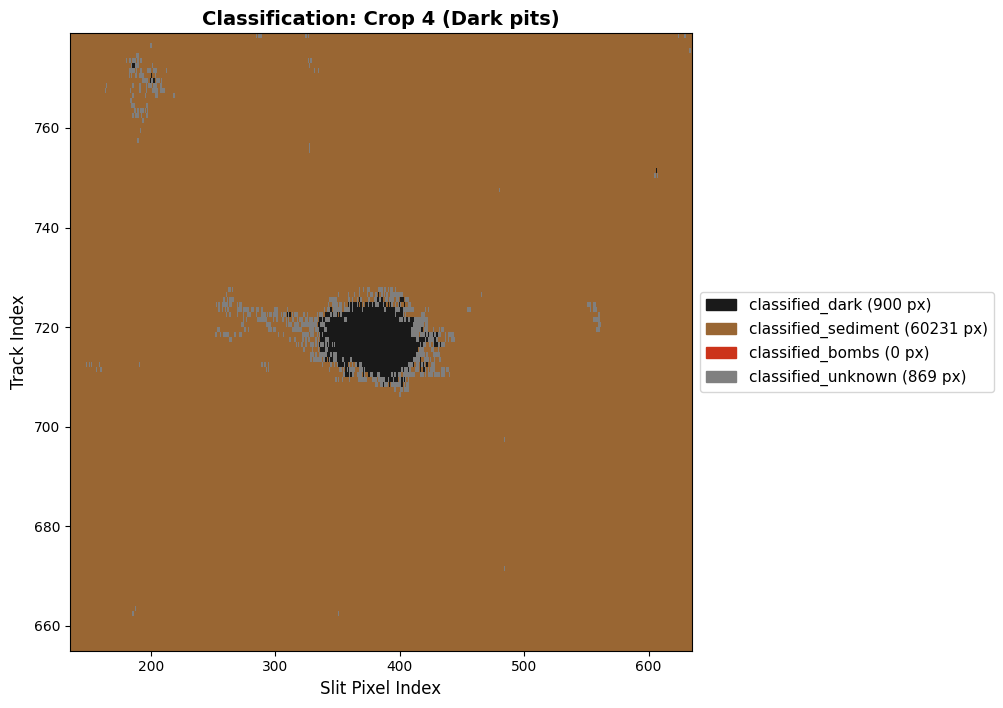

In [12]:
%matplotlib inline

def plot_classification_as_image(
    cube,
    crop,
    classification_map,
    class_names,
    figsize=(30, 8.32),
    flip_axes=True,
    flip_horizontal=True,
):
    """
    Plot classification results as a proper classified image (not ROI markers).
    Each pixel gets the color of its class - like a normal image.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # Define colors for each class - FIXED to match actual class names from classify_segment
    class_colors = {
        # Dev33 classes (from classify_segment output - prefixed with "classified_")
        "classified_dark": [0.1, 0.1, 0.1],  # Dark gray/black
        "classified_sediment": [0.6, 0.4, 0.2],  # Brown
        "classified_bombs": [0.8, 0.2, 0.1],  # Red-orange
        "classified_unknown": [0.5, 0.5, 0.5],  # Medium gray
        # Original training names (just in case)
        "training_dark": [0.1, 0.1, 0.1],  # Dark gray/black
        "training_sediment": [0.6, 0.4, 0.2],  # Brown
        "training_bombs": [0.8, 0.2, 0.1],  # Red-orange
        # Dev30 classes
        "sediment": [0.6, 0.4, 0.2],  # Brown
        "rust": [0.8, 0.2, 0.1],  # Red-orange
        "dark_bomb": [0.1, 0.1, 0.1],  # Dark gray/black
        "dark_pit": [0.2, 0.2, 0.2],  # Gray
        "halo": [0.9, 0.9, 0.5],  # Yellow
        "uncertain": [0.5, 0.5, 0.5],  # Medium gray
    }

    # Create RGB image from classification map
    height, width = classification_map.shape
    rgb_image = np.zeros((height, width, 3))

    for class_name in class_names:
        mask = classification_map == class_name
        color = class_colors.get(class_name, [0.5, 0.5, 0.5])  # Default gray
        rgb_image[mask] = color

    # Apply flipping to match plot_rgb behavior
    # Step 1: Transpose to match plot_rgb's initial .T.copy()
    rgb_image = rgb_image.transpose(1, 0, 2)  # (slits, tracks, 3)

    # Step 2: Apply flip_axes (like plot_rgb does)
    if flip_axes:
        rgb_image = rgb_image.transpose(1, 0, 2)  # Back to (tracks, slits, 3)

    # Step 3: Apply flip_horizontal (like plot_rgb does)
    if flip_horizontal:
        rgb_image = np.flip(rgb_image, axis=1)  # Flip along axis 1

    # Calculate extent in global coordinates
    half_width_slit = crop["width"] // 2
    half_width_track = int(crop["width"] / crop["aspect_ratio"] / 2)

    slit_min = crop["slit"] - half_width_slit
    slit_max = crop["slit"] + half_width_slit
    track_min = crop["track"] - half_width_track
    track_max = crop["track"] + half_width_track

    if flip_axes:
        # When axes flipped: x=slit, y=track (matches plot_rgb)
        extent = [slit_min, slit_max, track_min, track_max]
        xlabel, ylabel = "Slit Pixel Index", "Track Index"
    else:
        # Normal: x=track, y=slit
        extent = [track_min, track_max, slit_min, slit_max]
        xlabel, ylabel = "Track Index", "Slit Pixel Index"

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Display the classified image
    im = ax.imshow(
        rgb_image,
        extent=extent,
        origin="lower",
        aspect=crop.get("display_aspect_ratio", 4.0),
        interpolation="nearest",
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Classification: {crop['name']}", fontsize=14, fontweight="bold")

    # Create legend with class colors
    legend_patches = []
    for class_name in class_names:
        count = np.sum(classification_map == class_name)
        color = class_colors.get(class_name, [0.5, 0.5, 0.5])
        label = f"{class_name} ({count} px)"
        legend_patches.append(mpatches.Patch(color=color, label=label))

    ax.legend(
        handles=legend_patches,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

    return fig, ax


# Plot classification results as proper images (not ROI markers)
print("📊 Plotting classification as IMAGES (not ROI markers)...")

for crop_result in crop_results:  # FIXED: Use crop_results instead of multiclass_crop_results
    crop = crop_result["crop"]
    results = crop_result["results"]

    print(f"\n📍 {crop['name']}")
    print(f"   Classes: {results['class_names']}")

    # CRITICAL FIX: Crop the classification_map to the slit range!
    # classify_segment only crops track dimension, not slit dimension
    half_width_slit = crop["width"] // 2
    crop_slit_min = max(0, crop["slit"] - half_width_slit)
    crop_slit_max = min(
        results["classification_map"].shape[1], crop["slit"] + half_width_slit
    )

    # Crop the classification map to the slit range
    cropped_classification_map = results["classification_map"][
        :, crop_slit_min:crop_slit_max
    ]

    print(f"   Original shape: {results['classification_map'].shape}")
    print(
        f"   Cropped to slit [{crop_slit_min}:{crop_slit_max}]: {cropped_classification_map.shape}"
    )
    print(f"   Pixel counts:")
    for class_name in results["class_names"]:
        count = np.sum(cropped_classification_map == class_name)
        percentage = 100.0 * count / cropped_classification_map.size
        print(f"      {class_name}: {count} pixels ({percentage:.1f}%)")

    # Plot as proper classified image with CROPPED data
    plot_classification_as_image(
        cube,
        crop,
        cropped_classification_map,  # Use CROPPED classification map!
        results["class_names"],
        figsize=(30, 7.18),
        flip_axes=True,
        flip_horizontal=True,
    )